Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [2]:
# ===== STEP 1: IMPORT REQUIRED LIBRARIES =====
# These libraries are essential for data manipulation and visualization
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# ===== LOADING THE DATASET =====
# Reading the Algerian forest fires dataset which contains weather and fire data
pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv")

,,,,,,,,,,,,,Bejaia Region Dataset
day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire
27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [4]:
# ===== LOADING THE DATASET =====
# Reading the Algerian forest fires dataset which contains weather and fire data
df=pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv",header=1)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [5]:
# Check data types, missing values, and overall dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


### Data Cleaning

In [6]:
# ===== DATA QUALITY CHECK =====
# Identify rows with missing values (NULL/NaN)
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [7]:
# ===== DATA QUALITY CHECK =====
# Identify rows with missing values (NULL/NaN)
df.isnull().any(axis=1)#will return mask 
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


dataset is converted into two sets based on 'Region' from 122th index,we can make new column based on the Region.
1:"Bejaia Region"
2:"Siddi-Bel abbes" 

In [8]:
# ===== CREATE REGION COLUMN =====
# Split data into two regions:
# Region 0: Bejaia Region (rows 0-122)
# Region 1: Sidi-Bel Abbes (rows 122+)
df.loc[0:122,"Region"]=0
df.loc[122:,"Region"]=1
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [9]:
# Convert Region column to integer type
df[['Region']]=df[['Region']].astype(int)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [10]:
# Check data types, missing values, and overall dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       246 non-null    int32 
dtypes: int32(1), object(14)
memory usage: 28.0+ KB


In [11]:
# ===== DATA QUALITY CHECK =====
# Identify rows with missing values (NULL/NaN)
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [12]:
# ===== HANDLE MISSING VALUES =====
# Remove rows with missing values and reset index
df=df.dropna().reset_index(drop=True)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [13]:
# ===== DATA QUALITY CHECK =====
# Identify rows with missing values (NULL/NaN)
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [14]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [15]:
# Remove the problematic row 122 that marked region boundary
# remove 122nd row
df=df.drop(122).reset_index(drop=True)

In [16]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [17]:
df.columns## extra space present in column name eg."Classes "

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [18]:
# ===== CLEAN COLUMN NAMES =====
# Remove extra whitespace from column names
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [19]:
# Check data types, missing values, and overall dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int32 
dtypes: int32(1), object(14)
memory usage: 27.7+ KB


### changing required column's as integer data type

In [20]:
# Check data types, missing values, and overall dataset info
df[['month','day','year','Temperature','RH','Ws']]=df[['month','day','year','Temperature','RH','Ws']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int32 
 1   month        243 non-null    int32 
 2   year         243 non-null    int32 
 3   Temperature  243 non-null    int32 
 4   RH           243 non-null    int32 
 5   Ws           243 non-null    int32 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int32 
dtypes: int32(7), object(8)
memory usage: 22.0+ KB


In [21]:
### changing other columns to float(generic way to change datatype instead of specifying each column)
object_cols=[features for features in df.columns if df[features].dtypes=='O']
#alternate way
'''object_feature=df.select_dtypes(include=['object']).columns.tolist()'''

"object_feature=df.select_dtypes(include=['object']).columns.tolist()"

In [22]:
#except 'Classes' change datatype of all columns to float
for i in object_cols:
    if i!='Classes':
        df[i]=df[i].astype(float)

In [23]:
# Check data types, missing values, and overall dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int32  
 1   month        243 non-null    int32  
 2   year         243 non-null    int32  
 3   Temperature  243 non-null    int32  
 4   RH           243 non-null    int32  
 5   Ws           243 non-null    int32  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int32  
dtypes: float64(7), int32(7), object(1)
memory usage: 22.0+ KB


In [24]:
# Save the cleaned dataset for future use
#Saved cleaned dataset
df.to_csv("Cleaned_Dataset.csv",index=False)

### EDA


We are doing regression problem : predicting values for feature "FWI"

In [25]:
# Remove temporal columns (day, month, year) as they're not needed for regression
df_copy=df.drop(['day','month','year'],axis=1)
df_copy.head()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [26]:
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [27]:
# ===== ENCODE TARGET VARIABLE =====
# Convert 'fire' and 'not fire' to binary: 1 = fire, 0 = not fire
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [28]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

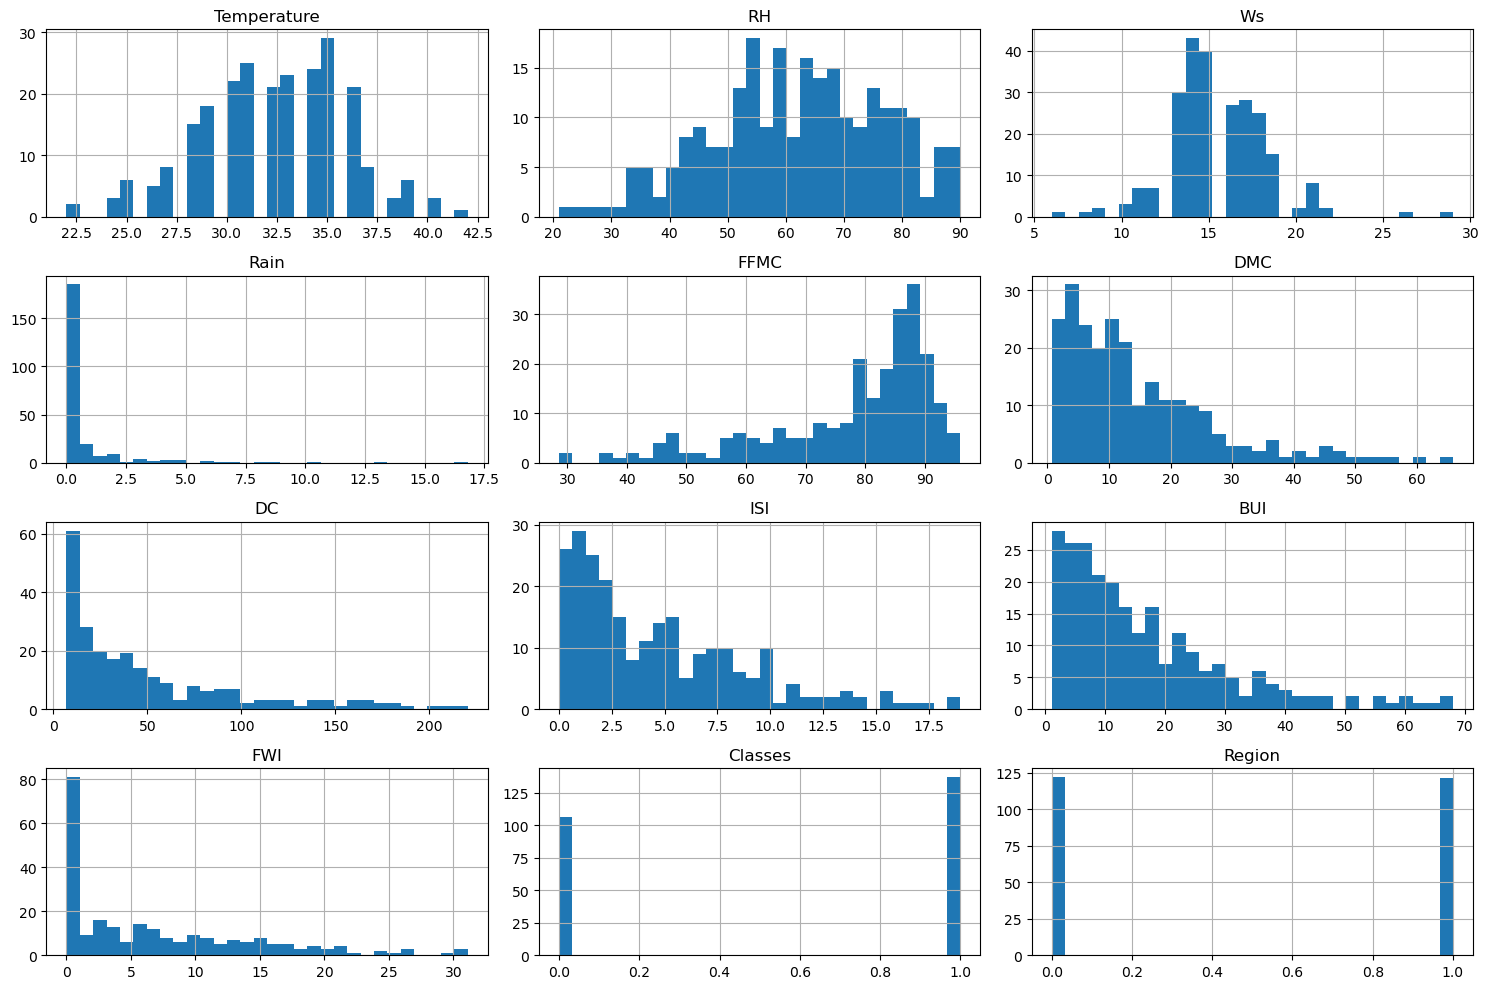

In [29]:
# ===== EXPLORATORY DATA ANALYSIS (EDA) =====
# Visualize distribution of all features to understand data patterns
df_copy.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [30]:
# Check correlation between features
# FWI is our target variable - see which features correlate with it
df_copy.corr()#FWI is dependent feature so focus on it

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

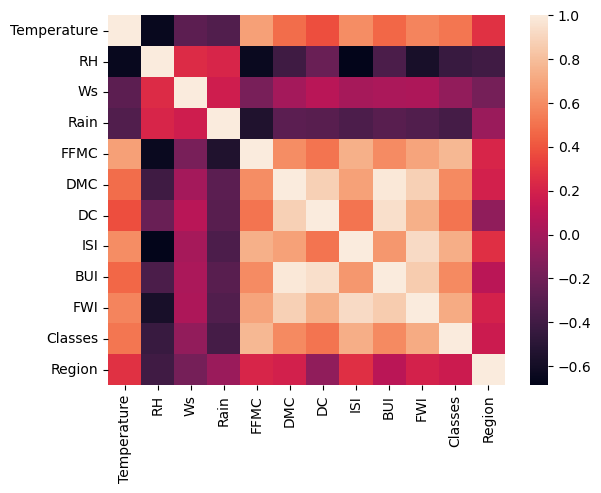

In [31]:
# Visualize feature correlations using a heatmap
sns.heatmap(df_copy.corr())

<Axes: xlabel='FWI'>

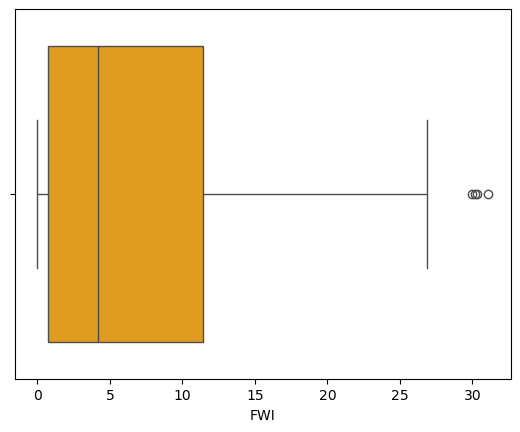

In [32]:
# Check for outliers in Fire Weather Index (FWI) values
sns.boxplot(df_copy['FWI'],color='Orange',orient='h')

In [33]:
# ===== ENCODE TARGET VARIABLE =====
# Convert 'fire' and 'not fire' to binary: 1 = fire, 0 = not fire
df['Classes']=np.where(df['Classes'].str.contains("not fire"),'not fire','fire')

Text(0.5, 1.0, 'Fire Analysis of sidi-Bel Region')

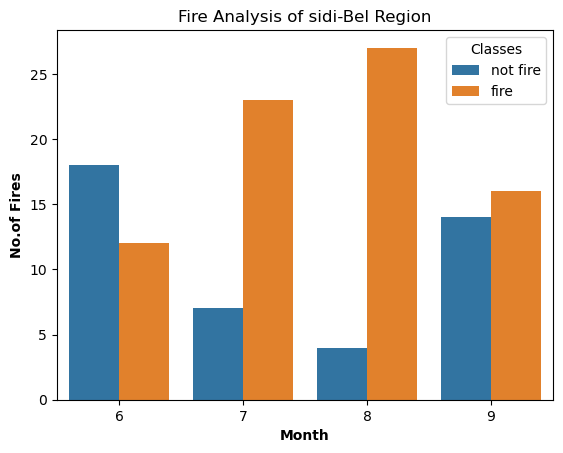

In [34]:
# ===== CREATE REGION COLUMN =====
# Split data into two regions:
# Region 0: Bejaia Region (rows 0-122)
# Region 1: Sidi-Bel Abbes (rows 122+)
dftemp=df.loc[df['Region']==1]
plt.subplot()
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.xlabel('Month',weight='bold')
plt.ylabel('No.of Fires',weight='bold')
plt.title("Fire Analysis of sidi-Bel Region")

Text(0.5, 1.0, 'Fire Analysis of Bijaia Region')

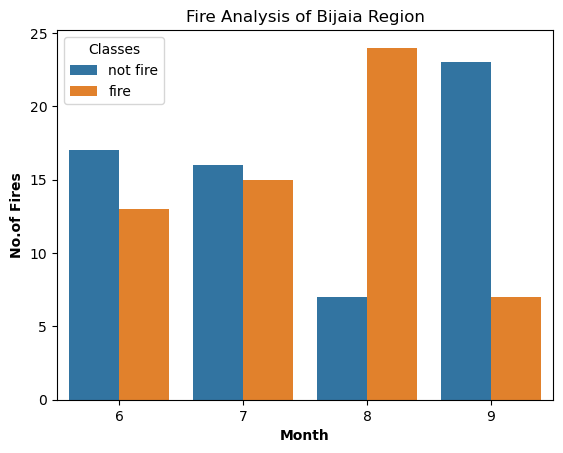

In [35]:
# ===== CREATE REGION COLUMN =====
# Split data into two regions:
# Region 0: Bejaia Region (rows 0-122)
# Region 1: Sidi-Bel Abbes (rows 122+)
dftemp=df.loc[df['Region']==0]
plt.subplot()
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.xlabel('Month',weight='bold')
plt.ylabel('No.of Fires',weight='bold')
plt.title("Fire Analysis of Bijaia Region")

## Model Training

In [37]:
# ===== LOAD CLEANED DATA FOR MODEL TRAINING =====
dataF=pd.read_csv("Cleaned_Dataset.csv")
dataF.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [38]:
dataF.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
# Remove temporal features that don't contribute to fire index prediction
dataF.drop(['day','month','year'],axis=1,inplace=True)

In [ ]:
dataF.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
# ===== ENCODE TARGET VARIABLE =====
# Convert 'fire' and 'not fire' to binary: 1 = fire, 0 = not fire
#encoding
dataF['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [47]:
dataF['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

#### Independent & dependent features

In [48]:
# ===== PREPARE FEATURES AND TARGET =====
# X = Independent features (weather and fire indices except FWI)
# y = Dependent variable (Fire Weather Index we want to predict)
X=dataF.drop('FWI',axis=1)#all features except "FWI"
y=dataF['FWI']

In [49]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [51]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

#### Train - test split


In [54]:
# ===== SPLIT DATA INTO TRAIN AND TEST SETS =====
# 75% for training, 25% for testing (random_state=42 for reproducibility)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [55]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

#### Feature selection based on correlation

In [57]:
# Check correlation between features
# FWI is our target variable - see which features correlate with it
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


#### check for multi-collinearity

<Axes: >

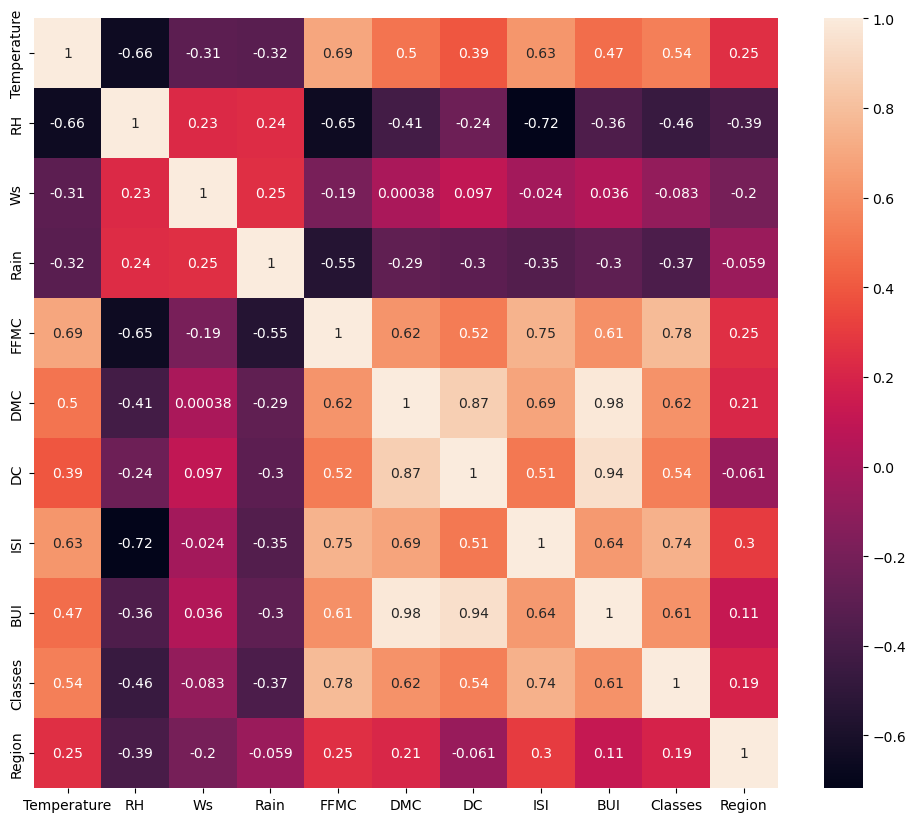

In [60]:
# Visualize feature correlations using a heatmap
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(),annot=True)

In [69]:
# ===== FEATURE SELECTION: REMOVE MULTICOLLINEARITY =====
# Function to find features that are highly correlated (>threshold)
# Multicollinearity can make models unreliable
#find feature which is having correlation > thrshold
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if(abs(corr_matrix.iloc[i,j])>threshold):
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

corr_features=correlation(X_train,0.85)

In [70]:
# Remove temporal features that don't contribute to fire index prediction
#drop this features
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)


In [72]:
X_train.shape,X_test.shape

((182, 9), (61, 9))

#### Feature scaling/ Standardization

In [73]:
# ===== FEATURE SCALING / STANDARDIZATION =====
# Normalize features to have mean=0 and std=1
# This improves model performance and convergence
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [74]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

'\nall have median near equals to 0\n'

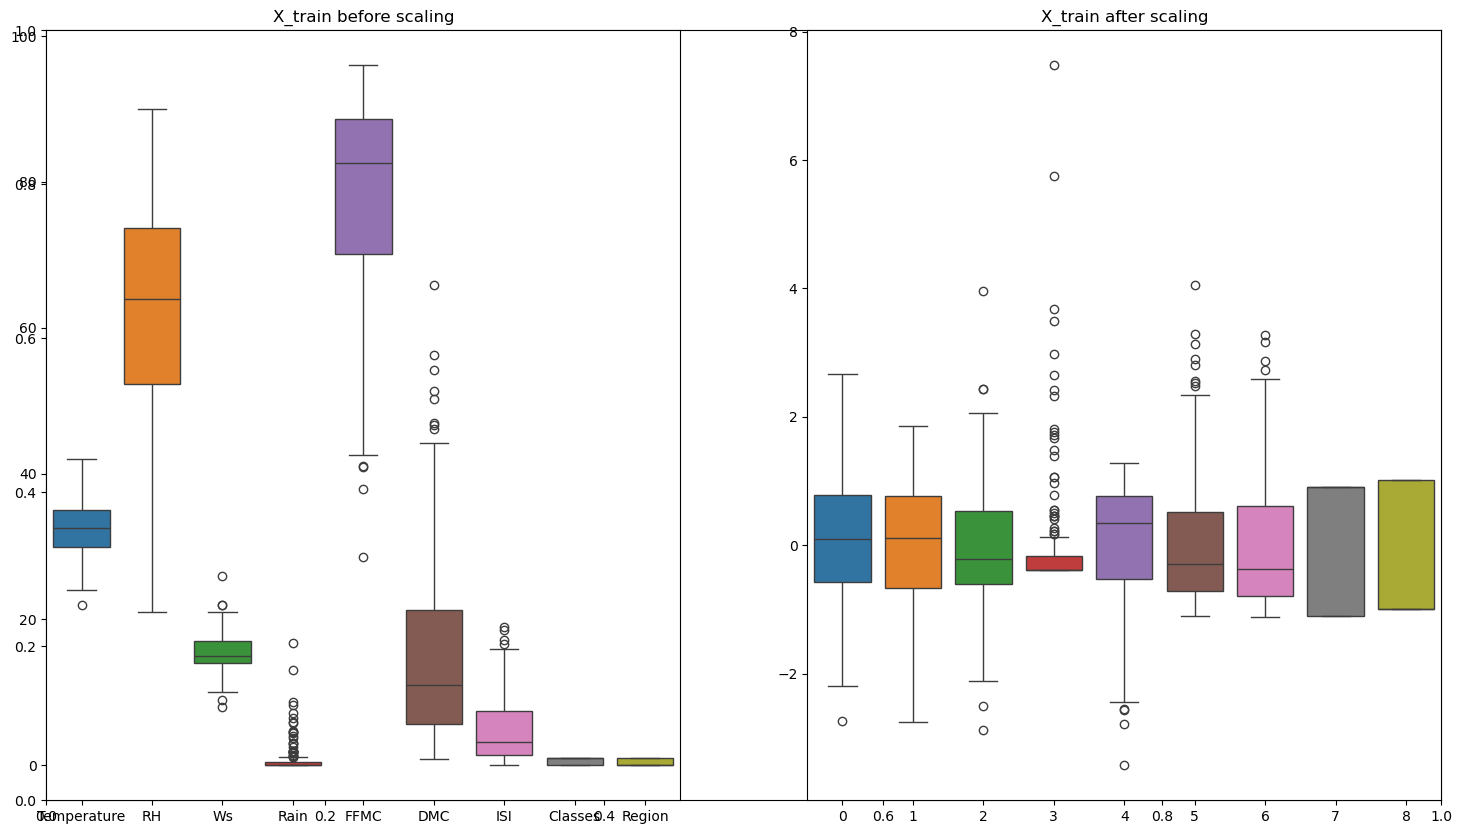

In [82]:
# Visualize the effect of standardization on data distribution
#Box plot to understand the effect of Standard scaling
plt.subplots(figsize=(18,10))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train after scaling")

'''
all have median near equals to 0
'''

### linear regression model

Mean absolute error :  0.5468236465249993
R2 score :  0.9847657384266951


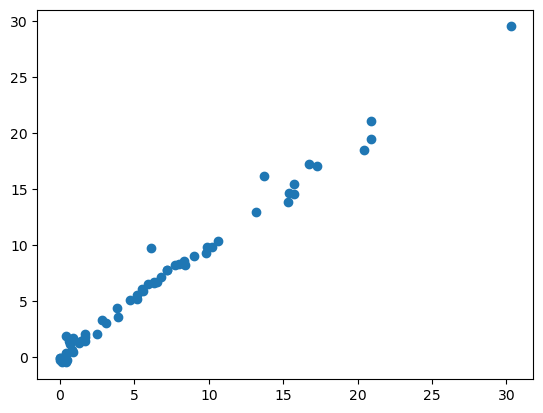

In [85]:
# ===== MODEL 1: LINEAR REGRESSION =====
# Simplest regression model - fits a linear relationship
# Formula: y = mx + b
# Advantages: Interpretable, fast, good baseline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg_model=LinearRegression()
linreg_model.fit(X_train_scaled,y_train)
y_pred=linreg_model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
print("Mean absolute error : ",mae)
r2=r2_score(y_test,y_pred)
print("R2 score : ",r2)
plt.scatter(y_test,y_pred)


### Lasso regression

Mean absolute error :  1.1331759949144085
R2 score :  0.9492020263112388


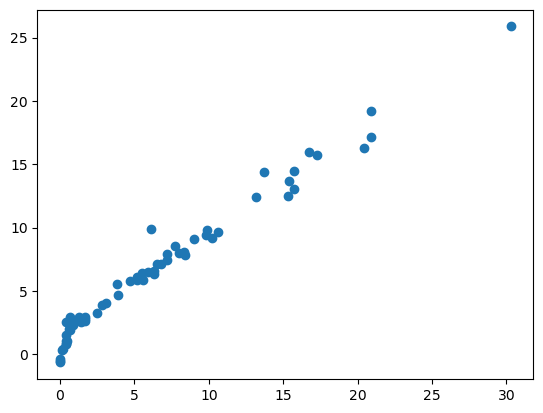

In [88]:
# ===== MODEL 2: LASSO REGRESSION =====
# Adds L1 penalty (Least Absolute Shrinkage and Selection Operator)
# Good for feature selection and reducing overfitting
# Can shrink some coefficients to zero
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lasso_model=Lasso()
lasso_model.fit(X_train_scaled,y_train)
y_pred=lasso_model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
print("Mean absolute error : ",mae)
r2=r2_score(y_test,y_pred)
print("R2 score : ",r2)
plt.scatter(y_test,y_pred)


### ridge regression

Mean absolute error :  0.5642305340105717
R2 score :  0.9842993364555513


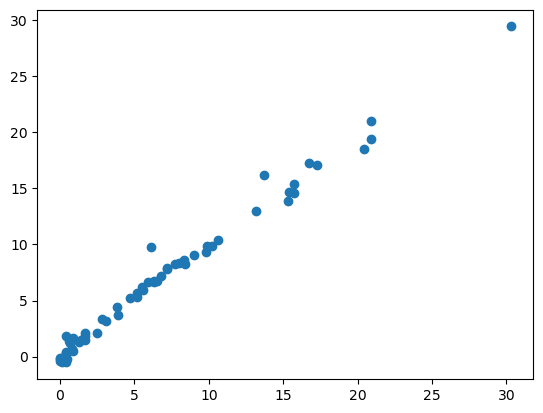

In [89]:
# ===== MODEL 3: RIDGE REGRESSION =====
# Adds L2 penalty to handle multicollinearity
# Better at preventing overfitting than Linear Regression
# Keeps all features but shrinks their coefficients
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
rig_model=Ridge()
rig_model.fit(X_train_scaled,y_train)
y_pred=rig_model.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
print("Mean absolute error : ",mae)
r2=r2_score(y_test,y_pred)
print("R2 score : ",r2)
plt.scatter(y_test,y_pred)
